# Deepfake Detection — Optimized Pipeline

### All fixes applied:
- Video-level train/val split — no frames from the same video span both sets
- Minimum 2-second gap enforced between sampled frames (reads actual FPS)
- 8 train frames / 5 val frames per video
- OpenCV DNN face detector (ResNet-10 SSD) — no mediapipe dependency
- Correct input size: 299x299 for Xception
- Separate clean val generator — zero augmentation on val
- Two-stage fine-tuning: train head first, then unfreeze top 50 Xception layers
- Deeper head: Dense(256) -> Dense(64) -> Dense(1)
- AUC metric + ReduceLROnPlateau + EarlyStopping

### Expected Drive structure:
```
MyDrive/deepfake_project/
    dataset/
        original/      <- real .mp4 files
        Deepfakes/     <- deepfake .mp4 files
```

## Cell 1 — Mount Drive & Download DNN Face Detector

In [3]:
from google.colab import drive
drive.mount('/content/drive')

import os

MODEL_DIR = '/content/face_model'
os.makedirs(MODEL_DIR, exist_ok=True)

# Use wget — handles GitHub binary redirects reliably unlike urllib
!wget -q -O /content/face_model/deploy.prototxt \
    "https://raw.githubusercontent.com/opencv/opencv/master/samples/dnn/face_detector/deploy.prototxt"

!wget -q -O /content/face_model/res10_300x300.caffemodel \
    "https://github.com/opencv/opencv_3rdparty/raw/dnn_samples_face_detector_20170830/res10_300x300_ssd_iter_140000.caffemodel"

# Verify both files downloaded and are non-empty
prototxt   = '/content/face_model/deploy.prototxt'
caffemodel = '/content/face_model/res10_300x300.caffemodel'

proto_size = os.path.getsize(prototxt)   if os.path.exists(prototxt)   else 0
caffe_size = os.path.getsize(caffemodel) if os.path.exists(caffemodel) else 0

print(f'deploy.prototxt       : {proto_size:,} bytes')
print(f'res10_300x300.caffemodel: {caffe_size:,} bytes')

if proto_size > 1000 and caffe_size > 1_000_000:
    print('Both files downloaded successfully')
else:
    print('ERROR: One or both files are missing or too small — check your internet connection and re-run')

Mounted at /content/drive
deploy.prototxt       : 28,104 bytes
res10_300x300.caffemodel: 10,666,211 bytes
Both files downloaded successfully


## Cell 2 — Imports & Config

In [4]:
import os
import cv2
import random
import shutil
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications import Xception
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# ── CONFIG — only edit this block ─────────────────────────────────────────
DRIVE_BASE       = '/content/drive/MyDrive/dataset'
SOURCE_REAL      = os.path.join(DRIVE_BASE, 'original')
SOURCE_FAKE      = os.path.join(DRIVE_BASE, 'Deepfakes')

# Local /content paths — faster I/O during training than reading from Drive
FACES_TRAIN_REAL = '/content/drive/MyDrive/faces/train/real'
FACES_TRAIN_FAKE = '/content/drive/MyDrive/faces/train/fake'
FACES_VAL_REAL   = '/content/drive/MyDrive/faces/val/real'
FACES_VAL_FAKE   = '/content/drive/MyDrive/faces/val/fake'
TRAIN_DIR        = '/content/drive/MyDrive/faces/train'
VAL_DIR          = '/content/drive/MyDrive/faces/val'

# Best model saved to Drive so it survives session end
MODEL_SAVE_PATH  = os.path.join(DRIVE_BASE, 'best_deepfake_model.keras')

# DNN face detector model files (downloaded in Cell 1)
DNN_PROTOTXT     = '/content/face_model/deploy.prototxt'
DNN_CAFFEMODEL   = '/content/face_model/res10_300x300.caffemodel'

IMG_SIZE         = (299, 299)  # Xception native resolution
BATCH_SIZE       = 16
TRAIN_FRAMES     = 8           # frames extracted per video for training
VAL_FRAMES       = 5           # frames extracted per video for validation
MIN_GAP_SECONDS  = 2.0         # minimum time between sampled frames
VAL_SPLIT_RATIO  = 0.2         # 20% of videos held out for validation
RANDOM_SEED      = 42
# ──────────────────────────────────────────────────────────────────────────

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

print('TensorFlow:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))
print('Config loaded')

TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Config loaded


## Cell 3 — Video-Level Train/Val Split (prevents data leakage)

In [5]:
def video_level_split(source_folder, val_ratio=0.2, seed=42):
    """
    Splits video filenames into train/val at the VIDEO level.
    Frames are only extracted AFTER the split, so no frames from
    the same video can appear in both train and val sets.

    Without this, np.linspace frame extraction + random val_split
    can put frame 30 of a video in train and frame 60 of the same
    video in val. The model then sees the same face/compression
    signature in both sets — leakage that inflates val accuracy.
    """
    random.seed(seed)
    videos = sorted([v for v in os.listdir(source_folder) if v.endswith('.mp4')])
    random.shuffle(videos)
    split_idx    = int(len(videos) * (1 - val_ratio))
    train_videos = videos[:split_idx]
    val_videos   = videos[split_idx:]
    return train_videos, val_videos


train_real, val_real = video_level_split(SOURCE_REAL, VAL_SPLIT_RATIO, RANDOM_SEED)
train_fake, val_fake = video_level_split(SOURCE_FAKE, VAL_SPLIT_RATIO, RANDOM_SEED)

print(f'Real  — train: {len(train_real)} videos | val: {len(val_real)} videos')
print(f'Fake  — train: {len(train_fake)} videos | val: {len(val_fake)} videos')
print('Video-level split complete — zero leakage between train and val')

Real  — train: 160 videos | val: 40 videos
Fake  — train: 152 videos | val: 39 videos
Video-level split complete — zero leakage between train and val


## Cell 4 — Face Extraction with OpenCV DNN + Time-Gap Enforcement

In [7]:
def detect_face(frame, net, conf_threshold=0.5):
    """
    OpenCV DNN face detector (ResNet-10 SSD).
    Returns (x, y, w, h) of the highest-confidence detection, or None.
    More reliable than Haar cascade for varied poses, lighting,
    and partial occlusion — all common in deepfake datasets.
    """
    h, w = frame.shape[:2]
    blob = cv2.dnn.blobFromImage(
        cv2.resize(frame, (300, 300)), 1.0,
        (300, 300), (104.0, 177.0, 123.0)
    )
    net.setInput(blob)
    detections = net.forward()
    best_conf  = 0
    best_box   = None
    for i in range(detections.shape[2]):
        confidence = float(detections[0, 0, i, 2])
        if confidence > conf_threshold and confidence > best_conf:
            best_conf = confidence
            box       = detections[0, 0, i, 3:7] * np.array([w, h, w, h])
            x1, y1, x2, y2 = box.astype(int)
            best_box  = (
                max(0, x1), max(0, y1),
                max(0, x2 - x1), max(0, y2 - y1)
            )
    return best_box


def sample_frame_indices(total_frames, fps, n_frames, min_gap_sec=2.0):
    """
    Returns frame indices spaced at least min_gap_sec seconds apart,
    evenly distributed across the usable portion of the video.

    Why this matters: np.linspace alone spaces frames by count, not time.
    On a 30fps video with 300 frames, 8 linspace points are only ~37
    frames apart — barely over 1 second. Faces that close in time are
    nearly identical and add no new information to the dataset.
    This function reads the actual FPS from each video and enforces
    a real time gap so each sample is meaningfully different.
    """
    min_gap_frames = int(fps * min_gap_sec)
    usable_start   = 30  # skip opening black/title frames
    usable_end     = max(total_frames - 5, usable_start + 1)
    usable_range   = usable_end - usable_start

    # Cap n_frames to how many can actually fit with the gap enforced
    max_possible = max(1, usable_range // min_gap_frames)
    n            = min(n_frames, max_possible)

    return np.linspace(usable_start, usable_end, n, dtype=int)


def extract_faces(video_names, source_folder, save_folder,
                  frames_per_video=8, img_size=(299, 299), min_gap_sec=2.0):
    """
    Extracts face crops from each video with time-gap enforcement.
    - Reads actual FPS from each video header (does not assume 30fps)
    - Enforces min_gap_sec between sampled frames
    - Adds 10% padding around each detected face crop
    - Skips videos shorter than 35 frames or with no detected face
    """
    os.makedirs(save_folder, exist_ok=True)
    net           = cv2.dnn.readNetFromCaffe(DNN_PROTOTXT, DNN_CAFFEMODEL)
    total_saved   = 0
    total_skipped = 0

    for vid_name in video_names:
        vid_path     = os.path.join(source_folder, vid_name)
        cap          = cv2.VideoCapture(vid_path)
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        fps          = cap.get(cv2.CAP_PROP_FPS) or 30.0

        if total_frames < 35:
            cap.release()
            total_skipped += 1
            continue

        sample_points = sample_frame_indices(
            total_frames, fps, frames_per_video, min_gap_sec
        )

        for i, frame_idx in enumerate(sample_points):
            cap.set(cv2.CAP_PROP_POS_FRAMES, int(frame_idx))
            success, frame = cap.read()
            if not success:
                continue

            bbox = detect_face(frame, net)
            if bbox is None:
                continue

            x, y, w, h = bbox
            pad_x = int(w * 0.10)
            pad_y = int(h * 0.10)
            x1    = max(0, x - pad_x)
            y1    = max(0, y - pad_y)
            x2    = min(frame.shape[1], x + w + pad_x)
            y2    = min(frame.shape[0], y + h + pad_y)

            face_crop = frame[y1:y2, x1:x2]
            if face_crop.size == 0:
                continue

            face_resized = cv2.resize(face_crop, img_size)
            save_name    = vid_name.replace('.mp4', f'_f{i:02d}.jpg')
            cv2.imwrite(os.path.join(save_folder, save_name), face_resized)
            total_saved += 1

        cap.release()

    print(f'  Saved: {total_saved} | Skipped (too short / no face): {total_skipped}')
    return total_saved


# Clear any stale extraction from previous runs
for d in [FACES_TRAIN_REAL, FACES_TRAIN_FAKE, FACES_VAL_REAL, FACES_VAL_FAKE]:
    if os.path.exists(d):
        shutil.rmtree(d)

print('Extracting TRAIN faces...')
print('  Real:', end=' ')
extract_faces(train_real, SOURCE_REAL, FACES_TRAIN_REAL, TRAIN_FRAMES, IMG_SIZE, MIN_GAP_SECONDS)
print('  Fake:', end=' ')
extract_faces(train_fake, SOURCE_FAKE, FACES_TRAIN_FAKE, TRAIN_FRAMES, IMG_SIZE, MIN_GAP_SECONDS)

print('Extracting VAL faces...')
print('  Real:', end=' ')
extract_faces(val_real, SOURCE_REAL, FACES_VAL_REAL, VAL_FRAMES, IMG_SIZE, MIN_GAP_SECONDS)
print('  Fake:', end=' ')
extract_faces(val_fake, SOURCE_FAKE, FACES_VAL_FAKE, VAL_FRAMES, IMG_SIZE, MIN_GAP_SECONDS)

def count_imgs(folder):
    return len([f for f in os.listdir(folder) if f.endswith('.jpg')])

tr_r = count_imgs(FACES_TRAIN_REAL)
tr_f = count_imgs(FACES_TRAIN_FAKE)
v_r  = count_imgs(FACES_VAL_REAL)
v_f  = count_imgs(FACES_VAL_FAKE)

print()
print('Dataset summary:')
print(f'  Train -> real: {tr_r} | fake: {tr_f} | total: {tr_r + tr_f}')
print(f'  Val   -> real: {v_r}  | fake: {v_f}  | total: {v_r  + v_f}')
print('Face extraction complete')

Extracting TRAIN faces...
  Real:   Saved: 1078 | Skipped (too short / no face): 0
  Fake:   Saved: 1024 | Skipped (too short / no face): 0
Extracting VAL faces...
  Real:   Saved: 195 | Skipped (too short / no face): 0
  Fake:   Saved: 189 | Skipped (too short / no face): 0

Dataset summary:
  Train -> real: 1078 | fake: 1024 | total: 2102
  Val   -> real: 195  | fake: 189  | total: 384
Face extraction complete


## Cell 5 — Data Generators (augmented train / clean val)

In [8]:
# Train: augmented to simulate real-world variability
#   horizontal_flip   — deepfake artefacts are often asymmetric
#   brightness_range  — lighting variation across cameras/sources
#   rotation/shift    — slight pose variation between frames
#   channel_shift     — simulates compression colour shifts
train_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.xception.preprocess_input,
    horizontal_flip=True,
    brightness_range=[0.75, 1.25],
    rotation_range=15,
    zoom_range=0.10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    channel_shift_range=20.0,
)

# Val: preprocessing only — no augmentation.
# Augmenting val data deflates accuracy and gives a misleading
# picture of real-world performance on unseen videos.
val_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.xception.preprocess_input,
)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True,
    seed=RANDOM_SEED
)

val_generator = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False   # deterministic order for consistent metrics
)

print('Class indices (train):', train_generator.class_indices)
print('Class indices (val):  ', val_generator.class_indices)
print(f'Train batches: {len(train_generator)} | Val batches: {len(val_generator)}')
print('Generators ready')

Found 2102 images belonging to 2 classes.
Found 384 images belonging to 2 classes.
Class indices (train): {'fake': 0, 'real': 1}
Class indices (val):   {'fake': 0, 'real': 1}
Train batches: 132 | Val batches: 24
Generators ready


## Cell 6 — Model Architecture (Xception + custom head)

In [11]:
def build_model(input_shape=(299, 299, 3)):
    """
    Xception-based deepfake detector.
    Returns (model, base_model) so Stage 1 and Stage 2 can freeze/unfreeze
    the base directly without going through model.layers — which is fragile
    across Keras versions.

    Head: GAP -> Dense(256, relu) -> Dropout(0.4)
              -> Dense(64,  relu) -> Dropout(0.3) -> Dense(1, sigmoid)
    """
    base_model = Xception(
        weights='imagenet', include_top=False, input_shape=input_shape
    )

    # Start fully frozen — Stage 1 trains only the head
    base_model.trainable = False

    x      = base_model.output
    x      = GlobalAveragePooling2D()(x)
    x      = Dense(256, activation='relu')(x)
    x      = Dropout(0.4)(x)
    x      = Dense(64,  activation='relu')(x)
    x      = Dropout(0.3)(x)
    output = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=base_model.input, outputs=output)
    return model, base_model


print('Building model...')
model, base_model = build_model(input_shape=(*IMG_SIZE, 3))
print(f'  Xception layers  : {len(base_model.layers)}')
print(f'  Total params     : {model.count_params():,}')
print(f'  Trainable params : {sum(tf.size(w).numpy() for w in model.trainable_weights):,}')
print('Model built')

Building model...
  Xception layers  : 132
  Total params     : 21,402,537
  Trainable params : 541,057
Model built


## Cell 7 — Stage 1: Train Head Only (base frozen)

In [12]:
# base_model.trainable = False is already set inside build_model.
# Only the Dense head layers receive gradient updates here.

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

print('Trainable params in Stage 1:',
      sum(tf.size(w).numpy() for w in model.trainable_weights))

stage1_callbacks = [
    EarlyStopping(
        monitor='val_auc', patience=4,
        restore_best_weights=True, mode='max'
    ),
]

print('Stage 1 — Training head only (base frozen)')
print('=' * 55)

history_s1 = model.fit(
    train_generator,
    epochs=8,
    validation_data=val_generator,
    callbacks=stage1_callbacks,
    verbose=1
)

print('Stage 1 complete')
print(f'  Best val accuracy : {max(history_s1.history["val_accuracy"]):.4f}')
print(f'  Best val AUC      : {max(history_s1.history["val_auc"]):.4f}')

Trainable params in Stage 1: 541057
Stage 1 — Training head only (base frozen)
Epoch 1/8
132/132 ━━━━━━━━━━━━━━━━━━━━ 145s 830ms/step - accuracy: 0.5909 - auc: 0.6300 - loss: 0.6705 - val_accuracy: 0.6641 - val_auc: 0.6824 - val_loss: 0.6370
Epoch 2/8
132/132 ━━━━━━━━━━━━━━━━━━━━ 66s 501ms/step - accuracy: 0.6751 - auc: 0.7402 - loss: 0.6012 - val_accuracy: 0.6823 - val_auc: 0.7414 - val_loss: 0.6235
Epoch 3/8
132/132 ━━━━━━━━━━━━━━━━━━━━ 69s 522ms/step - accuracy: 0.7098 - auc: 0.7862 - loss: 0.5575 - val_accuracy: 0.6641 - val_auc: 0.7066 - val_loss: 0.6272
Epoch 4/8
132/132 ━━━━━━━━━━━━━━━━━━━━ 69s 524ms/step - accuracy: 0.7383 - auc: 0.8156 - loss: 0.5266 - val_accuracy: 0.6901 - val_auc: 0.7447 - val_loss: 0.6208
Epoch 5/8
132/132 ━━━━━━━━━━━━━━━━━━━━ 66s 499ms/step - accuracy: 0.7650 - auc: 0.8491 - loss: 0.4808 - val_accuracy: 0.6823 - val_auc: 0.7407 - val_loss: 0.6223
Epoch 6/8
132/132 ━━━━━━━━━━━━━━━━━━━━ 66s 499ms/step - accuracy: 0.7835 - auc: 0.8673 - loss: 0.4559 - val_ac

In [1]:
for i, layer in enumerate(model.layers):
    print(i, layer.name, type(layer).__name__)

NameError: name 'model' is not defined

## Cell 8 — Stage 2: Fine-tune Top 50 Xception Layers

In [13]:
# Unfreeze top 50 of 132 Xception layers.
# Must recompile after changing trainable flags — otherwise the optimizer
# gradient tape still reflects the old frozen state and fine-tuning
# silently does nothing.

base_model.trainable = True
for layer in base_model.layers[:-50]:
    layer.trainable = False

trainable = sum(1 for l in base_model.layers if l.trainable)
print(f'Unfrozen base layers : {trainable} / {len(base_model.layers)}')
print(f'Trainable params now : {sum(tf.size(w).numpy() for w in model.trainable_weights):,}')

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

stage2_callbacks = [
    EarlyStopping(
        monitor='val_auc', patience=8,
        restore_best_weights=True, mode='max'
    ),
    ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=3, min_lr=1e-7, verbose=1
    ),
    ModelCheckpoint(
        MODEL_SAVE_PATH, save_best_only=True,
        monitor='val_auc', mode='max', verbose=1
    ),
]

print('Stage 2 — Fine-tuning top 50 Xception layers')
print('=' * 55)

history_s2 = model.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator,
    callbacks=stage2_callbacks,
    verbose=1
)

print('Stage 2 complete')
print(f'  Best val accuracy : {max(history_s2.history["val_accuracy"]):.4f}')
print(f'  Best val AUC      : {max(history_s2.history["val_auc"]):.4f}')
print(f'  Model saved to    : {MODEL_SAVE_PATH}')

Unfrozen base layers : 50 / 132
Trainable params now : 12,709,361
Stage 2 — Fine-tuning top 50 Xception layers
Epoch 1/30
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 719ms/step - accuracy: 0.6683 - auc: 0.7515 - loss: 0.6467
Epoch 1: val_auc improved from None to 0.79391, saving model to /content/drive/MyDrive/dataset/best_deepfake_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/dataset/best_deepfake_model.keras
132/132 ━━━━━━━━━━━━━━━━━━━━ 153s 863ms/step - accuracy: 0.7127 - auc: 0.7908 - loss: 0.5724 - val_accuracy: 0.6589 - val_auc: 0.7939 - val_loss: 0.7190 - learning_rate: 1.0000e-05
Epoch 2/30
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 511ms/step - accuracy: 0.7970 - auc: 0.8789 - loss: 0.4388
Epoch 2: val_auc improved from 0.79391 to 0.82317, saving model to /content/drive/MyDrive/dataset/best_deepfake_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/dataset/best_deepfake_model.keras
132/132 ━━━━━━━━━━━━━━━━━━━━ 72s 546ms/step - accuracy: 0.8049 - auc: 0.885

## Cell 9 — Training Curves

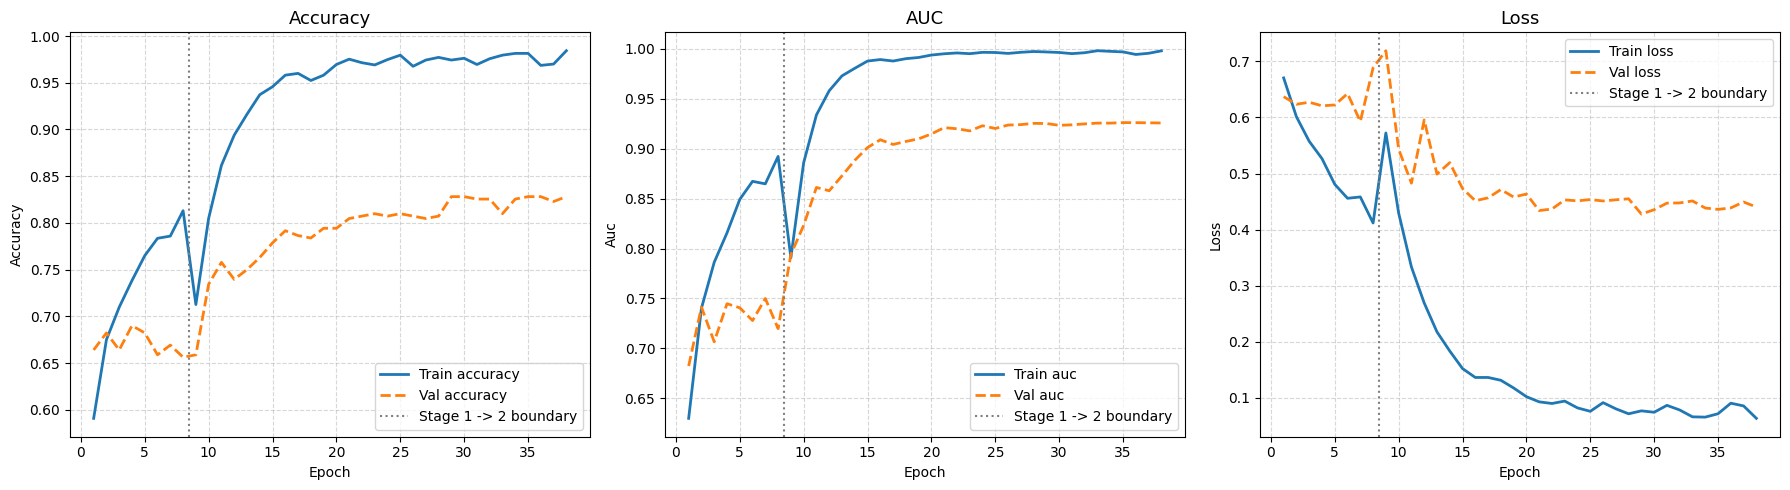

Curves saved to: /content/drive/MyDrive/dataset/training_curves.png


In [14]:
def plot_history(h1, h2, metric, title):
    s1_len  = len(h1.history[metric])
    s2_len  = len(h2.history[metric])
    train_v = h1.history[metric]          + h2.history[metric]
    val_v   = h1.history['val_' + metric] + h2.history['val_' + metric]
    epochs  = range(1, s1_len + s2_len + 1)
    plt.plot(epochs, train_v, label='Train ' + metric, linewidth=2)
    plt.plot(epochs, val_v,   label='Val '   + metric, linewidth=2, linestyle='--')
    plt.axvline(x=s1_len + 0.5, color='gray', linestyle=':',
                linewidth=1.5, label='Stage 1 -> 2 boundary')
    plt.title(title, fontsize=13)
    plt.xlabel('Epoch')
    plt.ylabel(metric.capitalize())
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)


fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plt.sca(axes[0]); plot_history(history_s1, history_s2, 'accuracy', 'Accuracy')
plt.sca(axes[1]); plot_history(history_s1, history_s2, 'auc',      'AUC')
plt.sca(axes[2]); plot_history(history_s1, history_s2, 'loss',     'Loss')
plt.tight_layout()

curves_path = os.path.join(DRIVE_BASE, 'training_curves.png')
plt.savefig(curves_path, dpi=150, bbox_inches='tight')
plt.show()
print('Curves saved to:', curves_path)

## Cell 10 — Evaluation: Confusion Matrix, ROC, Classification Report

Loaded: /content/drive/MyDrive/dataset/best_deepfake_model.keras
24/24 ━━━━━━━━━━━━━━━━━━━━ 22s 127ms/step


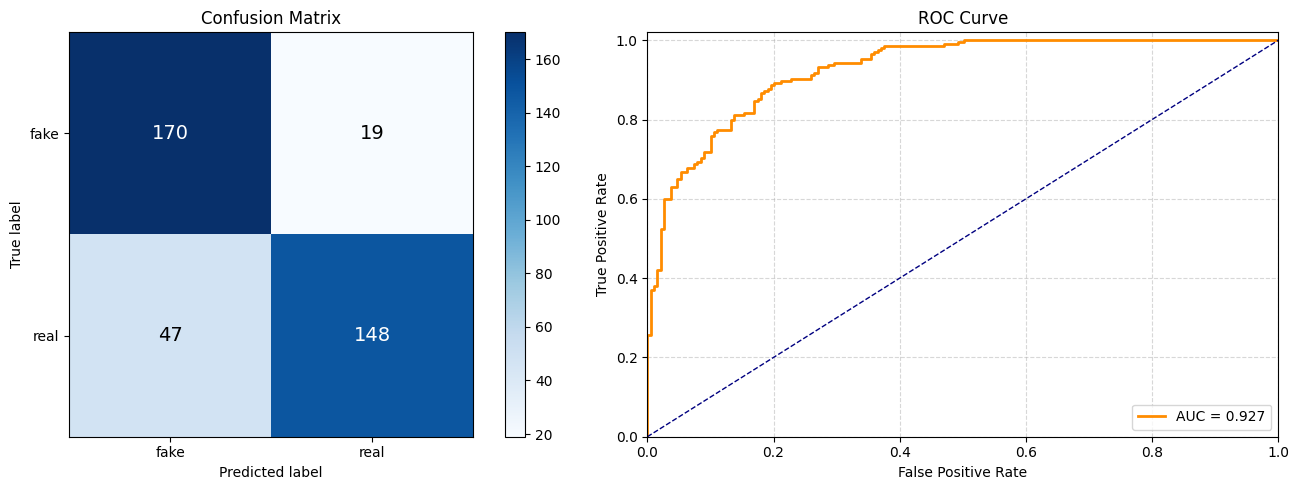

Classification Report
              precision    recall  f1-score   support

        fake       0.78      0.90      0.84       189
        real       0.89      0.76      0.82       195

    accuracy                           0.83       384
   macro avg       0.83      0.83      0.83       384
weighted avg       0.84      0.83      0.83       384

ROC-AUC: 0.9267


In [15]:
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc as sklearn_auc
import itertools

# Reload best checkpoint from Drive
best_model = tf.keras.models.load_model(MODEL_SAVE_PATH)
print('Loaded:', MODEL_SAVE_PATH)

val_generator.reset()
y_prob      = best_model.predict(val_generator, verbose=1).flatten()
y_pred      = (y_prob > 0.5).astype(int)
y_true      = val_generator.classes
class_names = list(val_generator.class_indices.keys())

cm = confusion_matrix(y_true, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
ax = axes[0]
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.colorbar(im, ax=ax)
ax.set(
    xticks=range(len(class_names)), yticks=range(len(class_names)),
    xticklabels=class_names, yticklabels=class_names,
    ylabel='True label', xlabel='Predicted label',
    title='Confusion Matrix'
)
thresh = cm.max() / 2
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    ax.text(j, i, cm[i, j], ha='center', va='center', fontsize=14,
            color='white' if cm[i, j] > thresh else 'black')

# ROC curve
fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc     = sklearn_auc(fpr, tpr)
ax = axes[1]
ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.3f}')
ax.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
ax.set(
    xlim=[0, 1], ylim=[0, 1.02],
    xlabel='False Positive Rate', ylabel='True Positive Rate',
    title='ROC Curve'
)
ax.legend(loc='lower right')
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
eval_path = os.path.join(DRIVE_BASE, 'evaluation.png')
plt.savefig(eval_path, dpi=150, bbox_inches='tight')
plt.show()

print('Classification Report')
print('=' * 50)
print(classification_report(y_true, y_pred, target_names=class_names))
print(f'ROC-AUC: {roc_auc:.4f}')

In [17]:
# Save the final model to Drive
model.save(MODEL_SAVE_PATH)
print(f'Model saved to: {MODEL_SAVE_PATH}')

# Verify it loads back correctly
loaded_model = tf.keras.models.load_model(MODEL_SAVE_PATH)
print(f'Verification — model loaded successfully')
print(f'Input shape  : {loaded_model.input_shape}')
print(f'Output shape : {loaded_model.output_shape}')

Model saved to: /content/drive/MyDrive/dataset/best_deepfake_model.keras
Verification — model loaded successfully
Input shape  : (None, 299, 299, 3)
Output shape : (None, 1)


## Cell 11 — Inference on a Single Video

In [16]:
def predict_video(video_path, model, num_frames=10,
                  img_size=(299, 299), threshold=0.5, min_gap_sec=2.0):
    """
    Samples num_frames from a video with min_gap_sec enforced,
    runs inference on each face crop, and aggregates by averaging
    sigmoid scores (soft voting across frames).

    Returns: label (str), mean_score (float), per_frame_scores (list)
    """
    preprocess   = tf.keras.applications.xception.preprocess_input
    net          = cv2.dnn.readNetFromCaffe(DNN_PROTOTXT, DNN_CAFFEMODEL)
    cap          = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps          = cap.get(cv2.CAP_PROP_FPS) or 30.0

    sample_pts   = sample_frame_indices(total_frames, fps, num_frames, min_gap_sec)
    scores, faces_rgb = [], []

    try:
        for frame_idx in sample_pts:
            cap.set(cv2.CAP_PROP_POS_FRAMES, int(frame_idx))
            success, frame = cap.read()
            if not success:
                continue
            bbox = detect_face(frame, net)
            if bbox is None:
                continue
            x, y, w, h = bbox
            face = cv2.resize(frame[y:y+h, x:x+w], img_size)
            faces_rgb.append(cv2.cvtColor(face, cv2.COLOR_BGR2RGB))
            inp   = preprocess(face.astype('float32'))
            inp   = np.expand_dims(inp, 0)
            score = float(model.predict(inp, verbose=0)[0][0])
            scores.append(score)
    finally:
        cap.release()

    if not scores:
        print('No faces detected in video.')
        return 'UNKNOWN', 0.0, []

    mean_score = float(np.mean(scores))
    label      = 'FAKE' if mean_score > threshold else 'REAL'

    cols = min(5, len(faces_rgb))
    rows = (len(faces_rgb) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
    axes = np.array(axes).flatten()
    for i, (face_img, sc) in enumerate(zip(faces_rgb, scores)):
        axes[i].imshow(face_img)
        axes[i].set_title(f'{sc:.3f}', fontsize=9,
                          color='red' if sc > threshold else 'green')
        axes[i].axis('off')
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
    color = 'red' if label == 'FAKE' else 'green'
    plt.suptitle(f'{label}  (mean: {mean_score:.3f})',
                 fontsize=13, weight='bold', color=color)
    plt.tight_layout()
    plt.show()

    return label, mean_score, scores


# Update this path to your test video
TEST_VIDEO = '/content/drive/MyDrive/deepfake_project/test_sample.mp4'

if os.path.exists(TEST_VIDEO):
    label, conf, frame_scores = predict_video(TEST_VIDEO, best_model)
    print(f'Video   : {os.path.basename(TEST_VIDEO)}')
    print(f'Verdict : {label}')
    print(f'Score   : {conf:.4f}  (> 0.5 = FAKE)')
    print(f'Frames  : {frame_scores}')
else:
    print(f'File not found: {TEST_VIDEO}')
    print('Update TEST_VIDEO and re-run.')

File not found: /content/drive/MyDrive/deepfake_project/test_sample.mp4
Update TEST_VIDEO and re-run.
